In [1]:
import pandas as pd

In [2]:
df = pd.read_excel('input_data.xlsx')
df

,id,time,code,roa,roe,tobinq,size,liq,lev,growth,...,mo,fo,so,org_own,board_size,ceo_board,female_board,female_ceo,board_age,board_edu
0,AAA,2012,AAA2012,6.927901e-14,0.108335,0.720850,27.526209,0.860651,0.415218,0.102711,...,0.0384,0.1326,0.0,0.1326,5,0,0.2,0,0.3822,1.0
1,AAA,2013,AAA2013,4.190296e-14,0.102074,0.824819,27.771278,1.211908,0.520222,0.277709,...,0.0384,0.1326,0.0,0.1326,5,0,0.2,0,0.3922,1.0
2,AAA,2014,AAA2014,2.364113e-14,0.061499,0.834076,27.982840,0.960340,0.446892,0.235606,...,0.0265,0.1326,0.0,0.1326,5,0,0.2,0,0.4022,1.0
3,AAA,2015,AAA2015,1.061180e-14,0.049481,0.892245,28.301291,1.367766,0.580775,0.374996,...,0.2841,0.1326,0.0,0.1326,5,0,0.2,1,0.4010,1.0
4,AAA,2016,AAA2016,1.508966e-14,0.149699,1.084386,28.755176,1.606347,0.689775,0.574418,...,0.4154,0.1150,0.0,0.1150,5,0,0.2,1,0.3911,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2221,VTH,2019,VTH2019,2.751267e-13,0.052472,0.784763,25.532776,2.504912,0.356791,0.166101,...,0.2712,0.0000,0.0,0.1169,5,0,0.4,0,0.4100,1.0
2222,VTH,2020,VTH2020,3.684449e-15,0.001129,0.794362,25.770412,2.152040,0.492263,0.268247,...,0.2926,0.0000,0.0,0.1169,4,0,0.0,1,0.4557,1.0
2223,VTH,2021,VTH2021,1.163959e-13,0.051031,0.891431,25.975725,1.627238,0.564267,0.489648,...,0.4031,0.0000,0.0,0.1169,3,0,0.0,1,0.3880,1.0
2224,VTH,2022,VTH2022,4.370196e-14,0.030656,0.914058,26.226289,1.311678,0.650116,0.059013,...,0.4582,0.0000,0.0,0.1169,3,0,0.0,1,0.3750,1.0


In [3]:
df.columns

Index(['id', 'time', 'code', 'roa', 'roe', 'tobinq', 'size', 'liq', 'lev',
       'growth', 'ocf', 'ppe', 'age', 'audit', 'covid', 'big_own', 'mo', 'fo',
       'so', 'org_own', 'board_size', 'ceo_board', 'female_board',
       'female_ceo', 'board_age', 'board_edu'],
      dtype='object')

## perform GMM

In [4]:
# === Gaussian Mixture clustering for credit grading ===
# Inputs: df with columns
# ['roa','roe','tobinq','size','liq','lev','growth','ocf','ppe','age','audit','covid',
#  'big_own','mo','fo','so','org_own','board_size','ceo_board','female_board',
#  'female_ceo','board_age','board_edu']

import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score

# 1) Select features
FEATURES = [
    'roa', 'roe', 'tobinq', 'size', 'liq', 'lev',
    'growth', 'ocf', 'ppe', 'age', 'audit', 'covid', 'big_own', 'mo', 'fo',
    'so', 'org_own', 'board_size', 'ceo_board', 'female_board',
    'female_ceo', 'board_age', 'board_edu'
]

X = df[FEATURES].copy()

# 2) Preprocess: median-impute then robust-scale
preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler(with_centering=True, with_scaling=True, quantile_range=(25.0, 75.0)))
])

X_scaled = preprocess.fit_transform(X)

# 3) Fit Gaussian Mixture with my chosen parameters
#    Five components = A..E grades, full covariance to allow correlated shapes
gmm = GaussianMixture(
    n_components=5,
    covariance_type="full",
    reg_covar=1e-6,
    init_params="kmeans",
    n_init=10,
    random_state=42
)
gmm.fit(X_scaled)

# 4) Assign clusters and soft probabilities
labels = gmm.predict(X_scaled)                    # hard assignment
proba = gmm.predict_proba(X_scaled).max(axis=1)   # confidence of assigned cluster

# 5) Optional diagnostics
sil = silhouette_score(X_scaled, labels)  # internal separation metric
bic = gmm.bic(X_scaled)
aic = gmm.aic(X_scaled)

print(f"Diagnostics - Silhouette: {sil:.3f} | BIC: {bic:,.0f} | AIC: {aic:,.0f}")
print("Cluster sizes:", pd.Series(labels).value_counts().sort_index().to_dict())

# 6) Profile clusters to understand their risk signatures (on original scale for readability)
X_imp = pd.DataFrame(preprocess.named_steps["imputer"].transform(X), columns=FEATURES, index=df.index)
cluster_profile = X_imp.assign(cluster=labels).groupby("cluster")[FEATURES].median().sort_index()
print("\nCluster median profile (original scale):")
print(cluster_profile)

# 7) Build a simple, theory-guided risk index to impose an order on clusters
#    Positive weights for safer attributes, negative for riskier ones.
risk_vars = ['lev', 'roa', 'roe', 'liq', 'ocf', 'size', 'age']
# weights aligned with credit intuition: leverage is strongly negative; profitability, liquidity,
# operating cash flow are positive; size and age moderately positive
risk_weights = np.array([-1.2, 1.0, 0.6, 0.6, 0.8, 0.3, 0.3])

# Standardize only these variables to zero mean and unit variance for the index
risk_scaler = StandardScaler()
Z = risk_scaler.fit_transform(df[risk_vars])

risk_score = Z.dot(risk_weights)

# Rank clusters by their median risk score (higher score = safer)
cluster_risk = pd.Series(risk_score, index=df.index).groupby(labels).median()
ordered_clusters = cluster_risk.sort_values(ascending=False).index.tolist()

# Map clusters to grades A..E in the safety order
def make_grade_letters(k):
    # up to 26 grades if ever needed
    letters = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
    assert k <= len(letters), "Too many clusters for the simple letter scale."
    return letters[:k]

grade_letters = make_grade_letters(len(ordered_clusters))
cluster_to_grade = {cl: grade_letters[i] for i, cl in enumerate(ordered_clusters)}

# Assign grade to each observation
grades = [cluster_to_grade[c] for c in labels]

# 8) Collect outputs
out = pd.DataFrame({
    "cluster": labels,
    "grade": grades,
    "cluster_probability": proba,
    "risk_score": risk_score
}, index=df.index)

# Merge a readable per-grade summary
grade_summary = (
    out.join(X_imp)
       .groupby("grade")[risk_vars + ["tobinq","growth","liq","lev","roa","ocf","size","age"]]
       .median()
       .sort_index()
)

print("\nCluster to grade mapping (by increasing risk):", cluster_to_grade)
print("\nGrade summary (median values, original scale):")
print(grade_summary)

# 9) Keep the fitted objects for future application on new periods
model_bundle = {
    "preprocess": preprocess,
    "gmm": gmm,
    "risk_scaler": risk_scaler,
    "risk_vars": risk_vars,
    "risk_weights": risk_weights,
    "cluster_to_grade": cluster_to_grade
}

# 10) Helper to apply the trained model to new dataframes with the same columns
def apply_credit_grades(new_df, bundle):
    X_new = new_df[FEATURES].copy()
    X_new_scaled = bundle["preprocess"].transform(X_new)
    labels_new = bundle["gmm"].predict(X_new_scaled)
    proba_new = bundle["gmm"].predict_proba(X_new_scaled).max(axis=1)

    # Risk score for ordering stability and monitoring
    Z_new = bundle["risk_scaler"].transform(new_df[bundle["risk_vars"]])
    risk_score_new = Z_new.dot(bundle["risk_weights"])

    grades_new = [bundle["cluster_to_grade"][c] for c in labels_new]

    return pd.DataFrame({
        "cluster": labels_new,
        "grade": grades_new,
        "cluster_probability": proba_new,
        "risk_score": risk_score_new
    }, index=new_df.index)

# Example:
# ratings_next = apply_credit_grades(df_next_period, model_bundle)

Diagnostics - Silhouette: 0.992 | BIC: 379,830 | AIC: 371,274
Cluster sizes: {0: 2219, 1: 1, 2: 3, 3: 1, 4: 2}

Cluster median profile (original scale):
                  roa       roe    tobinq       size       liq       lev  \
cluster                                                                    
0        6.919877e-14  0.114289  1.004392  27.354631  1.555660  0.438059   
1       -3.590414e+14  0.127566  2.337099  31.159046  2.915197  0.020582   
2        1.120664e+14  0.142266  2.808116  28.247411  2.061635  0.160541   
3       -6.858670e+14  0.047185  1.170605  31.988526  2.256828  0.084291   
4       -9.097010e+13  0.035813  0.882412  29.603723  2.814003  0.255745   

           growth       ocf       ppe   age  ...       mo   fo      so  \
cluster                                      ...                         
0        0.045880  0.076109  0.236286  16.0  ...  0.05400  0.0  0.0000   
1       -0.011851  0.097003  0.093684  20.0  ...  0.00000  0.0  0.3600   
2        0.002058 

In [5]:
grade_summary

,lev,roa,roe,liq,ocf,size,age,tobinq,growth,liq,lev,roa,ocf,size,age
grade,,,,,,,,,,,,,,,
A,0.160541,1.120664e+14,0.142266,2.061635,0.175708,28.247411,31.0,2.808116,0.002058,2.061635,0.160541,1.120664e+14,0.175708,28.247411,31.0
B,0.438059,6.919877e-14,0.114289,1.555660,0.076109,27.354631,16.0,1.004392,0.045880,1.555660,0.438059,6.919877e-14,0.076109,27.354631,16.0
C,0.255745,-9.097010e+13,0.035813,2.814003,0.132143,29.603723,31.5,0.882412,-0.162056,2.814003,0.255745,-9.097010e+13,0.132143,29.603723,31.5
D,0.020582,-3.590414e+14,0.127566,2.915197,0.097003,31.159046,20.0,2.337099,-0.011851,2.915197,0.020582,-3.590414e+14,0.097003,31.159046,20.0
E,0.084291,-6.858670e+14,0.047185,2.256828,0.046459,31.988526,28.0,1.170605,-0.004918,2.256828,0.084291,-6.858670e+14,0.046459,31.988526,28.0


In [18]:
# === Loop K = 3..10 and summarize metrics for Gaussian Mixture clustering ===
# Uses the same FEATURES and preprocessing as your grading pipeline.

import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.pipeline import Pipeline

FEATURES = [
    'roa','roe','tobinq','size','liq','lev','growth','ocf','ppe','age','audit','covid',
    'big_own','mo','fo','so','org_own','board_size','ceo_board','female_board',
    'female_ceo','board_age','board_edu'
]

def prepare_matrix(df, features=FEATURES):
    X = df[features].apply(pd.to_numeric, errors="coerce").copy()
    preprocess = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler(with_centering=True, with_scaling=True, quantile_range=(25.0, 75.0))),
    ])
    Xs = preprocess.fit_transform(X)
    return X, Xs, preprocess

def fit_gmm_metrics(X_scaled, k, random_state=42, reg_covar=1e-6, n_init=20, max_iter=500):
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        reg_covar=reg_covar,
        init_params="kmeans",
        n_init=n_init,
        max_iter=max_iter,
        random_state=random_state
    ).fit(X_scaled)

    labels = gmm.predict(X_scaled)
    proba  = gmm.predict_proba(X_scaled)
    conf   = proba.max(axis=1)

    # Internal validity
    try:
        sil = silhouette_score(X_scaled, labels)
    except Exception:
        sil = np.nan
    db  = davies_bouldin_score(X_scaled, labels)
    ch  = calinski_harabasz_score(X_scaled, labels)

    # Likelihood criteria
    bic = gmm.bic(X_scaled)
    aic = gmm.aic(X_scaled)

    # Membership entropy and ICL
    eps = 1e-12
    entropy_vec = -(proba * np.log(proba + eps)).sum(axis=1)
    mean_entropy = entropy_vec.mean()
    entropy_sum  = entropy_vec.sum()
    icl = bic + 2.0 * entropy_sum   # lower is better

    # Cluster sizes and minimum share
    counts = np.bincount(labels, minlength=k)
    min_share = counts.min() / len(labels)

    return {
        "k": k,
        "bic": bic,
        "icl": icl,
        "aic": aic,
        "silhouette": sil,
        "davies_bouldin": db,
        "calinski_harabasz": ch,
        "mean_entropy": mean_entropy,
        "median_confidence": np.median(conf),
        "min_cluster_share": min_share,
        "cluster_sizes": counts.tolist(),
        "model": gmm
    }

def compare_k(df, k_range=range(3, 11), min_share_threshold=0.02, min_silhouette=0.02, seed=42):
    X, Xs, preprocess = prepare_matrix(df, FEATURES)
    rng = np.random.RandomState(seed)
    rows = []
    for k in k_range:
        row = fit_gmm_metrics(
            X_scaled=Xs,
            k=k,
            random_state=int(rng.randint(0, 1_000_000)),
            reg_covar=1e-6,
            n_init=20,
            max_iter=500
        )
        rows.append(row)

    # Assemble results table
    results = pd.DataFrame([{k:v for k,v in r.items() if k != "model"} for r in rows]).sort_values("k")
    # Selection: lowest BIC among models that pass basic screens
    candidates = results[
        (results["min_cluster_share"] >= min_share_threshold) &
        (results["silhouette"].fillna(-1) >= min_silhouette)
    ]
    if len(candidates) > 0:
        best_k = int(candidates.sort_values("bic").iloc[0]["k"])
    else:
        best_k = int(results.sort_values("bic").iloc[0]["k"])

    # Retrieve best model object
    model_by_k = {r["k"]: r["model"] for r in rows}
    best_model = model_by_k[best_k]

    return best_k, results, best_model, preprocess

# ===== Run the comparison =====
best_k, k_results, best_gmm, preprocess = compare_k(
    df,
    k_range=range(3, 11),
    min_share_threshold=0.02,   # require each cluster to have at least 2 percent of obs
    min_silhouette=0.02,        # require minimal separation
    seed=42
)

print("Recommended K:", best_k)
display_cols = [
    "k","bic","icl","aic","silhouette","davies_bouldin","calinski_harabasz",
    "mean_entropy","median_confidence","min_cluster_share","cluster_sizes"
]
print("\nSummary by K:")
print(k_results[display_cols].to_string(index=False))

# If you want elbow-style plots:
# import matplotlib.pyplot as plt
# fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
# axes[0].plot(k_results["k"], k_results["bic"], marker="o"); axes[0].set_title("BIC vs K"); axes[0].set_xlabel("K"); axes[0].set_ylabel("BIC")
# axes[1].plot(k_results["k"], k_results["silhouette"], marker="o"); axes[1].set_title("Silhouette vs K"); axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette")
# axes[2].plot(k_results["k"], k_results["mean_entropy"], marker="o"); axes[2].set_title("Mean entropy vs K"); axes[2].set_xlabel("K"); axes[2].set_ylabel("Entropy")
# plt.tight_layout(); plt.show()

# You can now plug best_k into your grading code:
# gmm = GaussianMixture(n_components=best_k, covariance_type="full", reg_covar=1e-6,
#                       init_params="kmeans", n_init=10, random_state=42).fit(preprocess.transform(df[FEATURES]))

Recommended K: 3

Summary by K:
 k           bic           icl           aic  silhouette  davies_bouldin  calinski_harabasz  mean_entropy  median_confidence  min_cluster_share                      cluster_sizes
 3 378480.733818 378480.733818 373349.276401    0.992040        0.311135        7622.128504 -1.000089e-12                1.0           0.000898                       [2221, 2, 3]
 4 380273.859730 380273.859730 373430.013853    0.990879        0.231358       15071.993399 -1.000089e-12                1.0           0.000449                    [2220, 1, 1, 4]
 5 379829.768801 379829.768801 371273.534465    0.991565        0.250536       25357.376222 -1.000089e-12                1.0           0.000449                 [2219, 1, 1, 3, 2]
 6 380098.091680 380098.091680 369829.468885    0.986311        0.245259       26008.394566 -1.000089e-12                1.0           0.000449              [2216, 1, 1, 4, 1, 3]
 7 378577.569885 378577.569885 366596.558630    0.983539        0.227228 

In [19]:
k_results

,k,bic,icl,aic,silhouette,davies_bouldin,calinski_harabasz,mean_entropy,median_confidence,min_cluster_share,cluster_sizes
0,3,378480.733818,378480.733818,373349.276401,0.992040,0.311135,7622.128504,-1.000089e-12,1.0,0.000898,"[2221, 2, 3]"
1,4,380273.859730,380273.859730,373430.013853,0.990879,0.231358,15071.993399,-1.000089e-12,1.0,0.000449,"[2220, 1, 1, 4]"
2,5,379829.768801,379829.768801,371273.534465,0.991565,0.250536,25357.376222,-1.000089e-12,1.0,0.000449,"[2219, 1, 1, 3, 2]"
3,6,380098.091680,380098.091680,369829.468885,0.986311,0.245259,26008.394566,-1.000089e-12,1.0,0.000449,"[2216, 1, 1, 4, 1, 3]"
4,7,378577.569885,378577.569885,366596.558630,0.983539,0.227228,52956.081117,-1.000089e-12,1.0,0.000449,"[2207, 1, 1, 2, 1, 11, 3]"
5,8,379018.818556,379018.818556,365325.418841,0.979591,0.233575,87622.428546,-1.000089e-12,1.0,0.000449,"[2197, 1, 2, 1, 3, 19, 2, 1]"
6,9,379063.259707,379063.259707,363657.471533,0.972487,0.262106,105084.597969,3.404199e-13,1.0,0.000449,"[2186, 1, 1, 2, 1, 9, 3, 2, 21]"
7,10,381262.669514,381262.669514,364144.492880,0.972639,0.212456,138606.175774,3.404199e-13,1.0,0.000449,"[2186, 1, 1, 2, 1, 2, 2, 9, 21, 1]"


In [22]:
preprocess

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', RobustScaler())])

In [23]:
# ====== Imports ======
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.decomposition import PCA

# Use the exact same FEATURES list you used earlier
FEATURES = [
    'roa','roe','tobinq','size','liq','lev','growth','ocf','ppe','age','audit','covid',
    'big_own','mo','fo','so','org_own','board_size','ceo_board','female_board',
    'female_ceo','board_age','board_edu'
]

# =========================
# 1) Comparison charts across K
# =========================
def plot_line(x, y, title, xlab="K", ylab=""):
    plt.figure(figsize=(6,4))
    plt.plot(x, y, marker="o")
    plt.title(title)
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.grid(True)
    plt.show()

def plot_k_comparisons(k_results):
    # Sort by K for clean lines
    r = k_results.sort_values("k")
    x = r["k"].values

    plot_line(x, r["bic"].values, "BIC across K", ylab="BIC")
    plot_line(x, r["icl"].values, "ICL across K", ylab="ICL")
    plot_line(x, r["aic"].values, "AIC across K", ylab="AIC")

    plot_line(x, r["silhouette"].values, "Silhouette across K", ylab="Silhouette")
    plot_line(x, r["davies_bouldin"].values, "Davies Bouldin across K", ylab="Davies Bouldin")
    plot_line(x, r["calinski_harabasz"].values, "Calinski Harabasz across K", ylab="Calinski Harabasz")

    plot_line(x, r["mean_entropy"].values, "Mean membership entropy across K", ylab="Entropy")
    plot_line(x, r["median_confidence"].values, "Median assignment confidence across K", ylab="Confidence")
    plot_line(x, r["min_cluster_share"].values, "Minimum cluster share across K", ylab="Min share")

def plot_cluster_size_bars(k_results):
    # Bar chart for sizes for each K on separate figures
    r = k_results.sort_values("k")
    for _, row in r.iterrows():
        k = row["k"]
        sizes = row["cluster_sizes"]
        plt.figure(figsize=(6,4))
        plt.bar(range(k), sizes)
        plt.title(f"Cluster sizes for K = {k}")
        plt.xlabel("Cluster label")
        plt.ylabel("Count")
        plt.grid(True, axis="y")
        plt.show()

# =========================
# 2) Visuals for the chosen model
# =========================
def get_labels_and_matrix(df, best_gmm, preprocess):
    Xs = preprocess.transform(df[FEATURES])
    labels = best_gmm.predict(Xs)
    proba  = best_gmm.predict_proba(Xs).max(axis=1)
    return Xs, labels, proba

def plot_membership_histogram(proba):
    plt.figure(figsize=(6,4))
    plt.hist(proba, bins=25)
    plt.title("Histogram of assignment confidence")
    plt.xlabel("Max posterior probability")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

def plot_cluster_sizes(labels):
    counts = pd.Series(labels).value_counts().sort_index()
    plt.figure(figsize=(6,4))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title("Cluster sizes (chosen K)")
    plt.xlabel("Cluster")
    plt.ylabel("Count")
    plt.grid(True, axis="y")
    plt.show()

def plot_profile_heatmap(df, preprocess, labels, features=None):
    """
    Heatmap of standardized feature means by cluster.
    Uses the same scaling as the fitted pipeline for comparability.
    """
    if features is None:
        features = FEATURES
    Xs = preprocess.transform(df[features])
    Z = pd.DataFrame(Xs, columns=features, index=df.index)
    prof = Z.assign(cluster=labels).groupby("cluster")[features].mean().sort_index()

    plt.figure(figsize=(max(6, 0.35*len(features)), 0.5*prof.shape[0] + 4))
    plt.imshow(prof.values, aspect="auto")
    plt.title("Standardized means by cluster")
    plt.xlabel("Feature")
    plt.ylabel("Cluster")
    plt.xticks(ticks=np.arange(len(features)), labels=features, rotation=90)
    plt.yticks(ticks=np.arange(prof.shape[0]), labels=prof.index.astype(str))
    plt.colorbar()
    plt.tight_layout()
    plt.show()

def plot_pca_scatter(df, preprocess, labels, best_gmm):
    """
    Two dimensional PCA scatter with Gaussian ellipses for clusters.
    The ellipses are one standard deviation contours in the PCA space
    by projecting each component’s mean and covariance.
    """
    Xs = preprocess.transform(df[FEATURES])
    pca = PCA(n_components=2, random_state=42)
    XY = pca.fit_transform(Xs)

    plt.figure(figsize=(6,5))
    # scatter by cluster
    for k in np.unique(labels):
        idx = (labels == k)
        plt.scatter(XY[idx,0], XY[idx,1], s=12, label=f"Cluster {k}")
    plt.title("PCA scatter of observations by cluster")
    plt.xlabel("PC1")
    plt.ylabel("PC2")

    # draw ellipses by projecting GMM parameters into PCA space
    means = best_gmm.means_
    covs  = best_gmm.covariances_
    means_2d = pca.transform(means)  # project means

    for k in range(best_gmm.n_components):
        # project covariance: Sigma_pca = P * Sigma * P^T
        P = pca.components_
        Sigma_k = covs[k]
        Sigma_2d = P @ Sigma_k @ P.T
        # eigen decomposition for ellipse axes
        vals, vecs = np.linalg.eigh(Sigma_2d)
        order = np.argsort(vals)[::-1]
        vals = vals[order]; vecs = vecs[:,order]
        angle = np.degrees(np.arctan2(vecs[1,0], vecs[0,0]))
        width, height = 2.0 * np.sqrt(vals)  # one standard deviation contour

        ell = Ellipse(xy=means_2d[k], width=width, height=height, angle=angle, fill=False)
        plt.gca().add_patch(ell)

    plt.legend(loc="best")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# =========================
# 3) Example usage
# =========================
# After you have best_k, k_results, best_gmm, preprocess from the selection code:
# 1) Compare K diagnostics
# plot_k_comparisons(k_results)
# plot_cluster_size_bars(k_results)

# 2) Visualize the chosen model
# X_scaled, labels, proba = get_labels_and_matrix(df, best_gmm, preprocess)
# plot_membership_histogram(proba)
# plot_cluster_sizes(labels)
# plot_profile_heatmap(df, preprocess, labels, features=FEATURES)
# plot_pca_scatter(df, preprocess, labels, best_gmm)

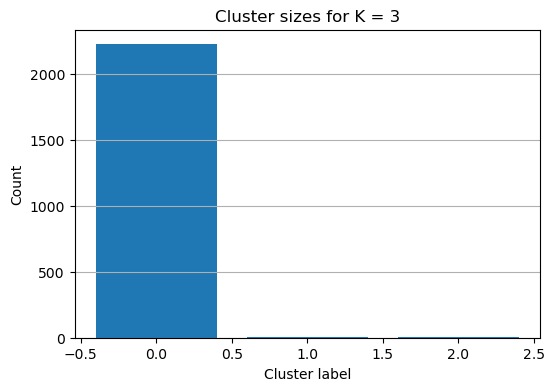

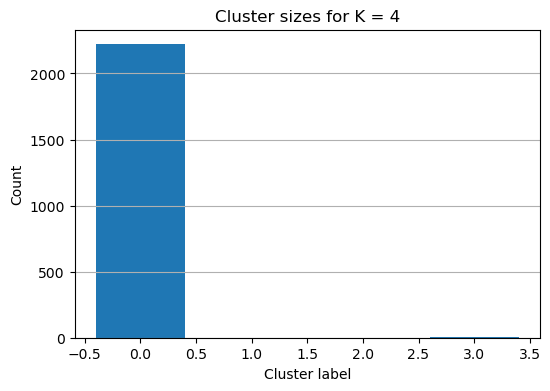

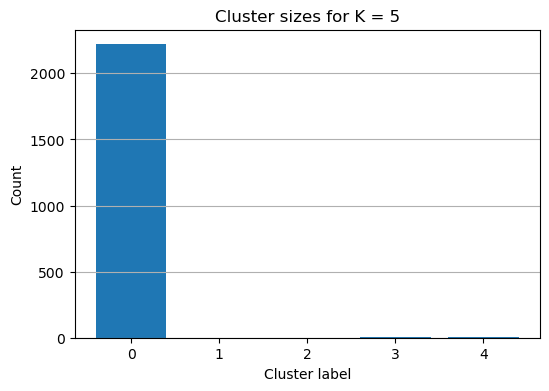

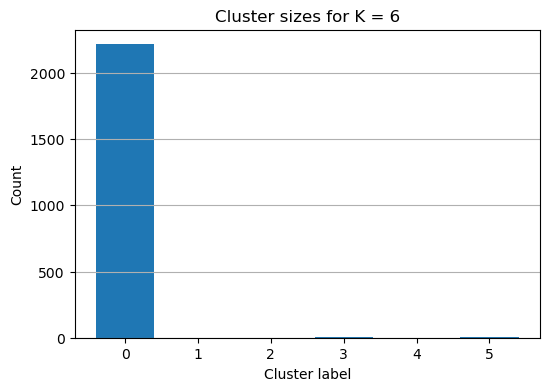

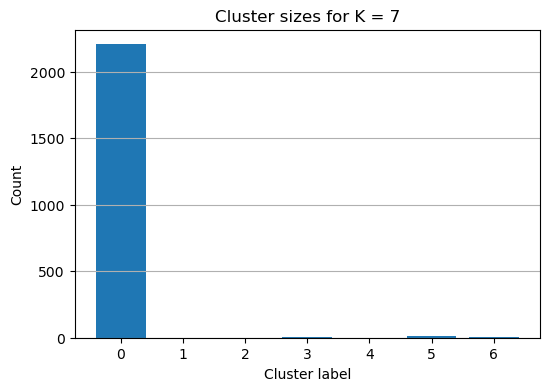

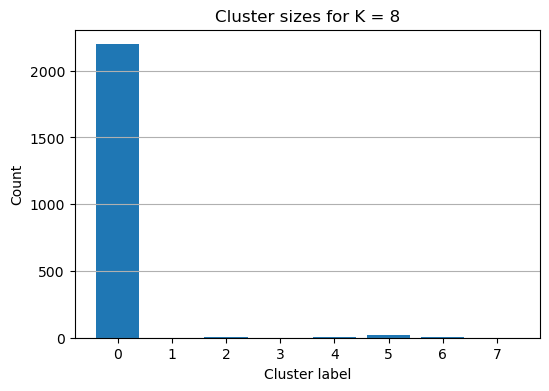

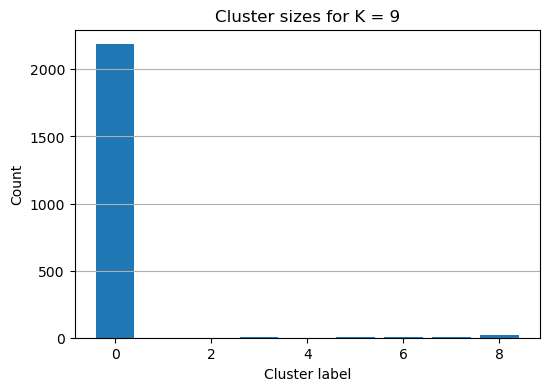

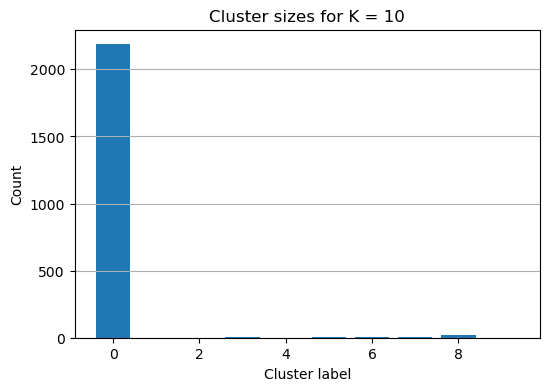

In [25]:
# 1) Compare K diagnostics
# plot_k_comparisons(k_results)
plot_cluster_size_bars(k_results)

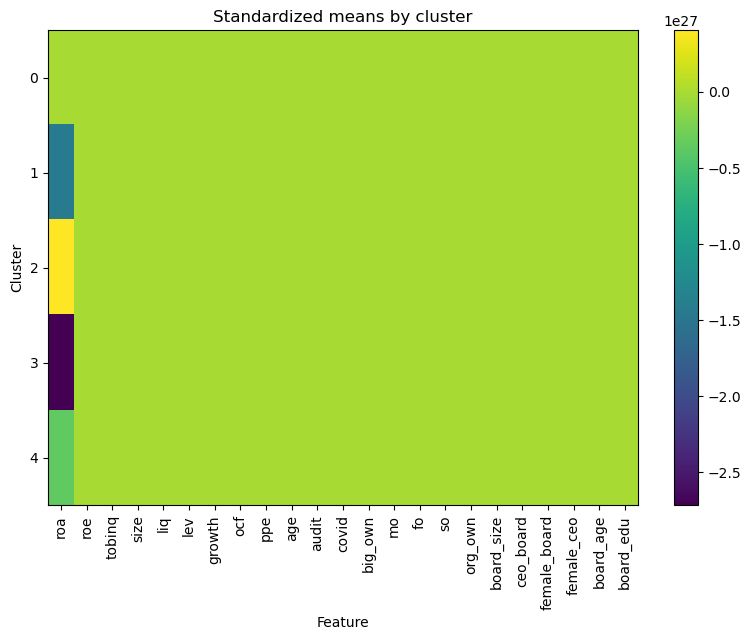

In [29]:
# 2) Visualize the chosen model
# X_scaled, labels, proba = get_labels_and_matrix(df, best_gmm, preprocess)
# plot_membership_histogram(proba)
# plot_cluster_sizes(labels)
plot_profile_heatmap(df, preprocess, labels, features=FEATURES)
# plot_pca_scatter(df, preprocess, labels, best_gmm)

In [26]:
best_gmm

GaussianMixture(max_iter=500, n_components=3, n_init=20, random_state=121958)

In [7]:
import numpy as np
import pandas as pd

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, roc_auc_score, brier_score_loss, roc_curve
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from scipy.optimize import linear_sum_assignment

# 1) Fit and separation on current fit
X_scaled = preprocess.transform(df[FEATURES])
labels = out["cluster"].values
proba_mat = gmm.predict_proba(X_scaled)
hard_conf = proba_mat.max(axis=1)

sil = silhouette_score(X_scaled, labels)
db  = davies_bouldin_score(X_scaled, labels)
ch  = calinski_harabasz_score(X_scaled, labels)
bic = gmm.bic(X_scaled)
aic = gmm.aic(X_scaled)

# Membership uncertainty: entropy per firm, then average by cluster
entropy = -(proba_mat * np.log(proba_mat + 1e-12)).sum(axis=1)
entropy_by_cluster = pd.Series(entropy).groupby(labels).mean()

print(f"Silhouette: {sil:.3f} | Davies–Bouldin: {db:.3f} | Calinski–Harabasz: {ch:,.1f}")
print(f"Bayesian Information Criterion: {bic:,.0f} | Akaike Information Criterion: {aic:,.0f}")
print("Mean entropy by cluster:", entropy_by_cluster.to_dict())
print("Assignment confidence, median by cluster:", pd.Series(hard_conf).groupby(labels).median().to_dict())

Silhouette: 0.992 | Davies–Bouldin: 0.251 | Calinski–Harabasz: 25,357.4
Bayesian Information Criterion: 379,830 | Akaike Information Criterion: 371,274
Mean entropy by cluster: {0: -1.000088900581841e-12, 1: -1.000088900581841e-12, 2: -1.000088900581841e-12, 3: -1.000088900581841e-12, 4: -1.000088900581841e-12}
Assignment confidence, median by cluster: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0}


In [ ]:
# 2) Heatmap-ready profile: standardized means by cluster
Z = pd.DataFrame(X_scaled, columns=FEATURES, index=df.index)
cluster_profile_z = Z.assign(cluster=labels).groupby("cluster")[FEATURES].mean().sort_index()

In [ ]:
# 3) Principal components for plotting ellipses later if desired
pca = PCA(n_components=2, random_state=42)
pc2 = pca.fit_transform(X_scaled)
pc_df = pd.DataFrame(pc2, columns=["PC1","PC2"]).assign(cluster=labels, grade=out["grade"].values)

In [12]:
# 4) Monotonicity check across grades for key risk variables
risk_vars = ["lev","liq","roa","ocf","size","age"]
grade_medians = df.join(out["grade"]).groupby("grade")[risk_vars].median().sort_index()
print("\nGrade medians for risk variables:\n", grade_medians)


Grade medians for risk variables:
             lev       liq           roa       ocf       size   age
grade                                                             
A      0.160541  2.061635  1.120664e+14  0.175708  28.247411  31.0
B      0.438059  1.552155  6.919877e-14  0.076109  27.354631  16.0
C      0.255745  2.814003 -9.097010e+13  0.132143  29.603723  31.5
D      0.020582  2.915197 -3.590414e+14  0.097003  31.159046  20.0
E      0.084291  2.256828 -6.858670e+14  0.046459  31.988526  28.0


In [11]:
# 5) External discrimination and calibration if future outcome exists
if "distress_next" in df.columns:
    # Use grade order as ordinal scores: A safer than B safer than C etc.
    grade_order = sorted(out["grade"].unique())  # A..E
    grade_to_num = {g:i for i,g in enumerate(grade_order[::-1], start=1)}  # A gets highest score
    scores = out["grade"].map(grade_to_num).values.astype(float)

    y = df["distress_next"].astype(int).values
    auc = roc_auc_score(y, scores)
    # Kolmogorov Smirnov: compare score distributions for bad vs good
    ks = ks_2samp(scores[y==1], scores[y==0]).statistic

    # CAP and Gini
    order = np.argsort(scores)[::-1]
    cum_bad = np.cumsum(y[order]) / y.sum() if y.sum() > 0 else np.zeros_like(y)
    cum_pop = np.arange(1, len(y)+1) / len(y)
    gini = 2 * np.trapz(cum_bad, cum_pop) - 1 if y.sum() > 0 else np.nan

    # Calibration by grade
    calib = df.join(out["grade"]).groupby("grade")["distress_next"].agg(["mean","count"])
    print(f"\nExternal discrimination: AUC={auc:.3f} | Kolmogorov Smirnov={ks:.3f} | Gini={gini:.3f}")
    print("Observed default rate by grade:\n", calib)

In [10]:
# 6) Transition matrix if you have firm_id and year and grades over time
if {"id","time"}.issubset(df.columns):
    grades_time = pd.concat([df[["firm_id","year"]], out["grade"]], axis=1)
    # one year transitions
    g0 = grades_time.copy()
    g1 = grades_time.copy()
    g1["year"] = g1["year"] - 1
    merged = g0.merge(g1, on=["firm_id","year"], suffixes=("_t","_t1"))
    trans = pd.crosstab(merged["grade_t1"], merged["grade_t"], normalize="index").reindex(index=sorted(out["grade"].unique()), columns=sorted(out["grade"].unique()))
    print("\nOne year transition matrix (rows start grade at t, columns grade at t+1):\n", trans.fillna(0).round(3))

KeyError: "None of [Index(['firm_id', 'year'], dtype='object')] are in the [columns]"

In [8]:
# 7) Bootstrap stability: Jaccard similarity of memberships across refits
def bootstrap_jaccard(X_scaled, base_labels, n_boot=10, n_components=5, reg_covar=1e-6, random_state=42):
    from sklearn.mixture import GaussianMixture
    rng = np.random.RandomState(random_state)
    N = X_scaled.shape[0]
    jac_list = []

    for b in range(n_boot):
        idx = rng.choice(N, size=N, replace=True)
        Xm = X_scaled[idx]
        g = GaussianMixture(n_components=n_components, covariance_type="full", reg_covar=reg_covar,
                            init_params="kmeans", n_init=5, random_state=rng.randint(0, 1_000_000)).fit(Xm)
        # Predict labels for the full sample using the bootstrap fit
        lab_new = g.predict(X_scaled)

        # Align labels by Hungarian matching on the confusion matrix
        K = len(np.unique(base_labels))
        conf = pd.crosstab(base_labels, lab_new).reindex(index=range(K), columns=range(K), fill_value=0).values
        row_ind, col_ind = linear_sum_assignment(conf.max() - conf)  # maximize matches
        mapping = {col: row for row, col in zip(row_ind, col_ind)}
        aligned = np.array([mapping[l] for l in lab_new])

        # Jaccard by cluster
        for k in range(K):
            A = set(np.where(base_labels == k)[0])
            B = set(np.where(aligned == k)[0])
            inter = len(A & B)
            union = len(A | B)
            jac = inter / union if union > 0 else np.nan
            jac_list.append(jac)
    return np.nanmean(jac_list), np.nanstd(jac_list)

mean_jac, std_jac = bootstrap_jaccard(X_scaled, labels, n_boot=10, n_components=gmm.n_components, reg_covar=gmm.reg_covar)
print(f"\nBootstrap Jaccard similarity of memberships: mean={mean_jac:.3f}, std={std_jac:.3f}")


Bootstrap Jaccard similarity of memberships: mean=0.582, std=0.432


In [33]:
import numpy as np, pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.pipeline import Pipeline

FEATURES = [
    'roe','size','liq','lev','growth','ocf','ppe','age','audit'
]

def _prepare(df):
    X = df[FEATURES].apply(pd.to_numeric, errors="coerce").copy()
    prep = Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("scl", RobustScaler(quantile_range=(25.0,75.0)))])
    Xs = prep.fit_transform(X)
    return X, Xs, prep

def _fit_gmm(Xs, k, seed):
    gmm = GaussianMixture(n_components=k, covariance_type="full",
                          reg_covar=1e-6, init_params="kmeans",
                          n_init=20, max_iter=500, random_state=seed).fit(Xs)
    lab = gmm.predict(Xs); proba = gmm.predict_proba(Xs)
    counts = np.bincount(lab, minlength=k); p = counts / counts.sum()
    eps = 1e-12
    H = -(p * np.log(p + eps)).sum() / np.log(k)                # 1.0 = perfectly balanced
    imb = 1.0 - H                                               # 0.0 = perfectly balanced
    sil = silhouette_score(Xs, lab) if len(np.unique(lab))>1 else np.nan
    return dict(
        k=k,
        bic=gmm.bic(Xs),
        aic=gmm.aic(Xs),
        silhouette=sil,
        davies_bouldin=davies_bouldin_score(Xs, lab),
        calinski_harabasz=calinski_harabasz_score(Xs, lab),
        balance_entropy=H,
        imbalance=imb,
        min_cluster_share=p.min(),
        cluster_sizes=counts.tolist(),
        model=gmm
    )

def compare_k_balanced(df, k_range=range(3,11), min_share=0.08, min_sil=0.03, alpha=25.0, seed=42):
    """
    alpha controls how hard we penalize imbalance in the selection score:
    bic_balanced = bic + alpha * N * imbalance
    """
    X, Xs, prep = _prepare(df)
    rng = np.random.RandomState(seed)
    rows = []
    for k in k_range:
        rows.append(_fit_gmm(Xs, k, int(rng.randint(0, 1_000_000))))
    res = pd.DataFrame([{k:v for k,v in r.items() if k!="model"} for r in rows]).sort_values("k")
    N = Xs.shape[0]
    res["bic_balanced"] = res["bic"] + alpha * N * res["imbalance"]

    # screen out pathological fits
    ok = res[(res["min_cluster_share"]>=min_share) & (res["silhouette"].fillna(-1)>=min_sil)]
    if len(ok)>0:
        best_k = int(ok.sort_values("bic_balanced").iloc[0]["k"])
    else:
        best_k = int(res.sort_values("bic_balanced").iloc[0]["k"])

    best_model = {r["k"]: r["model"] for r in rows}[best_k]
    return best_k, res, best_model, prep

# Usage
best_k, k_results, best_gmm, preprocess = compare_k_balanced(
    df, k_range=range(3,11), min_share=0.08, min_sil=0.03, alpha=25.0, seed=42
)

print("Recommended K:", best_k)
print(k_results[["k","bic","bic_balanced","silhouette","min_cluster_share","imbalance","cluster_sizes"]])


Recommended K: 8
    k           bic   bic_balanced  silhouette  min_cluster_share  imbalance  \
0   3  56276.857826  110030.224537    0.981727           0.000449   0.965919   
1   4  32079.570904   62256.679167    0.098935           0.000449   0.542266   
2   5  22224.790279   53044.418980    0.028644           0.000449   0.553812   
3   6  22403.493652   55537.689086    0.030322           0.000449   0.595403   
4   7  21426.154690   55954.703924    0.044541           0.000449   0.620459   
5   8  17929.500754   40273.537931    0.042272           0.000449   0.401510   
6   9  18165.405926   43010.908098    0.046587           0.000449   0.446460   
7  10  18230.051068   44126.435421    0.044488           0.000449   0.465344   

                                cluster_sizes  
0                               [2213, 12, 1]  
1                          [638, 12, 1, 1575]  
2                      [599, 12, 1, 1564, 50]  
3                   [599, 12, 1, 52, 1561, 1]  
4                [51, 